Machine learning Assignment: Customer segmentation and purchase prediction
Name: A H Mohammed Arif
Date: 2026-01-28

Part 1: Data Exploration and Preprocessing

1.1 Load and Inspect

In [101]:
import pandas as pd

# Load the customer dataset
df = pd.read_csv('customer_data.csv')



In [102]:
# Display the first 10 rows
df.head(10)

,customer_id,age,gender,city_tier,membership_type,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
0,CUST000878,29.0000,Female,Tier 3,Silver,465.0000,11,42.2700,50.0000,18.0000,4,15.5300,0
1,CUST004886,47.0000,Male,Tier 1,Platinum,4451.3200,23,193.5400,16.0000,38.0000,6,404.4500,1
2,CUST002485,37.0000,Male,Tier 1,Platinum,1903.0200,21,90.6200,29.0000,28.0000,5,207.8300,0
3,CUST002289,37.0000,Male,Tier 1,Platinum,3952.7500,23,171.8600,33.0000,31.0000,11,502.3000,1
4,CUST000812,25.0000,Male,Tier 1,Silver,1367.0700,11,124.2800,46.0000,18.0000,7,70.9300,0
5,CUST000249,36.0000,Female,Tier 2,Silver,160.1500,6,26.6900,39.0000,8.0000,3,8.9600,0
6,CUST003299,32.0000,Male,Tier 2,Gold,3440.7900,17,202.4000,29.0000,29.0000,6,304.4000,1
7,CUST000107,37.0000,Female,Tier 1,Silver,505.1700,6,84.2000,51.0000,15.0000,4,16.9300,0
8,CUST000280,26.0000,Female,Tier 3,Silver,2476.9600,9,275.2200,44.0000,10.0000,4,71.0100,0
9,CUST001282,27.0000,NaN,Tier 1,Silver,404.2400,12,33.6900,56.0000,17.0000,8,26.0700,0


In [103]:
# Check the shape of the dataset
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (5025, 13)
Number of rows: 5025
Number of columns: 13


In [104]:
# Display data types and check for null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   5025 non-null   object 
 1   age                           4723 non-null   float64
 2   gender                        4724 non-null   object 
 3   city_tier                     5025 non-null   object 
 4   membership_type               5025 non-null   object 
 5   total_spend                   5025 non-null   float64
 6   num_transactions              5025 non-null   int64  
 7   avg_transaction_value         5025 non-null   float64
 8   days_since_last_purchase      4723 non-null   float64
 9   num_visits                    4724 non-null   float64
 10  product_categories_purchased  5025 non-null   int64  
 11  discount_used                 5025 non-null   float64
 12  high_value_customer           5025 non-null   int64  
dtypes: 

In [105]:
# Generate summary statistics
df.describe()

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
count,4723.0000,5025.0000,5025.0000,5025.0000,4723.0000,4724.0000,5025.0000,5025.0000,5025.0000
mean,39.2795,3520.2703,15.0478,219.4074,29.4565,23.0326,6.7140,308.9587,0.3737
std,11.6083,3503.7052,7.6287,167.1711,13.1631,10.3625,3.1630,373.8243,0.4838
min,18.0000,11.5900,1.0000,1.7700,4.0000,3.0000,1.0000,0.4300,0.0000
25%,30.0000,1031.9700,9.0000,99.8300,19.0000,15.0000,4.0000,61.5300,0.0000
50%,38.0000,2258.3800,14.0000,176.0200,26.0000,21.0000,6.0000,166.8200,0.0000
75%,47.0000,4777.6000,20.0000,291.6200,41.0000,30.0000,9.0000,405.6000,1.0000
max,75.0000,27621.7800,43.0000,1500.1100,69.0000,59.0000,15.0000,3999.6600,1.0000


1.2 Handle Missing Values

In [106]:
# Identify columns with missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)
print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

Missing values per column:
customer_id                       0
age                             302
gender                          301
city_tier                         0
membership_type                   0
total_spend                       0
num_transactions                  0
avg_transaction_value             0
days_since_last_purchase        302
num_visits                      301
product_categories_purchased      0
discount_used                     0
high_value_customer               0
dtype: int64

Columns with missing values:
age                         302
gender                      301
days_since_last_purchase    302
num_visits                  301
dtype: int64


1.2 Handle Missing Values 

In [107]:
# Fill missing values: median for numerical, mode for categorical
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values for numerical columns with median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Fill missing values for categorical columns with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
customer_id                     0
age                             0
gender                          0
city_tier                       0
membership_type                 0
total_spend                     0
num_transactions                0
avg_transaction_value           0
days_since_last_purchase        0
num_visits                      0
product_categories_purchased    0
discount_used                   0
high_value_customer             0
dtype: int64


In [108]:
# Check for duplicate rows based on customer_id
initial_rows = len(df)
duplicates = df.duplicated(subset=['customer_id']).sum()

print(f"Total duplicate rows based on customer_id: {duplicates}")

# Remove duplicate rows, keeping the first occurrence
df.drop_duplicates(subset=['customer_id'], keep='first', inplace=True)

final_rows = len(df)
removed_rows = initial_rows - final_rows

print(f"\nInitial number of rows: {initial_rows}")
print(f"Final number of rows: {final_rows}")
print(f"Number of duplicate rows removed: {removed_rows}")

Total duplicate rows based on customer_id: 25

Initial number of rows: 5025
Final number of rows: 5000
Number of duplicate rows removed: 25


1.4 Exploratory Analysis 

In [109]:
# Display the distribution of categorical variables using value_counts()
print("Gender Distribution:")
print(df['gender'].value_counts())
print("\n" + "="*50 + "\n")

print("Membership Type Distribution:")
print(df['membership_type'].value_counts())
print("\n" + "="*50 + "\n")

print("High Value Customer Distribution:")
print(df['high_value_customer'].value_counts())

Gender Distribution:
gender
Female    2639
Male      2292
Other       69
Name: count, dtype: int64


Membership Type Distribution:
membership_type
Silver      1959
Gold        1911
Platinum    1130
Name: count, dtype: int64


High Value Customer Distribution:
high_value_customer
0    3129
1    1871
Name: count, dtype: int64


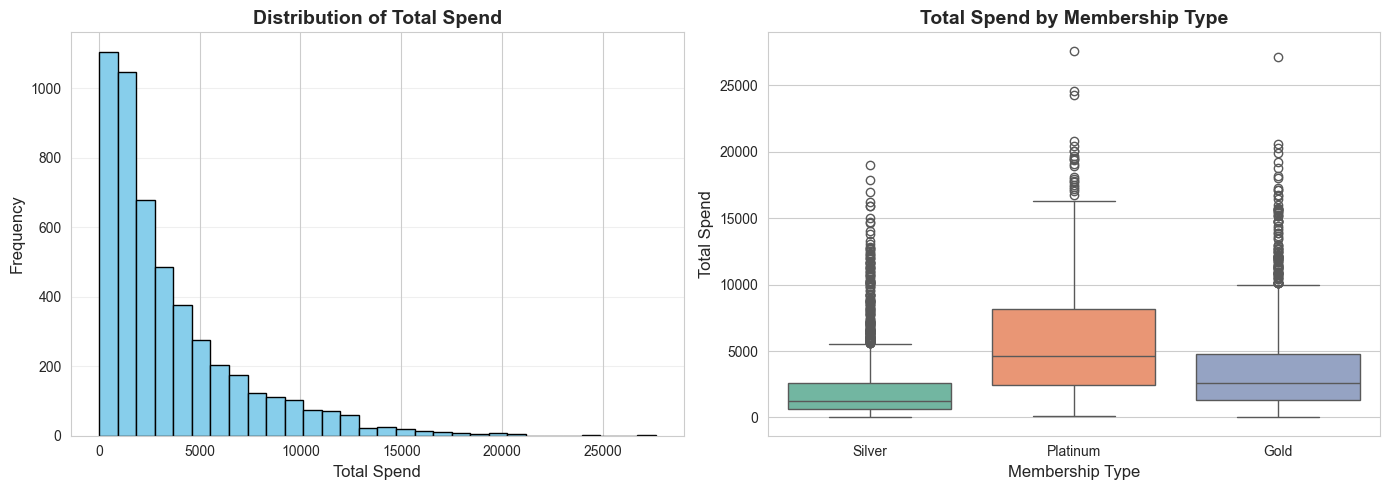

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better-looking plots
sns.set_style("whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualization 1: Histogram showing distribution of total_spend
axes[0].hist(df['total_spend'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Total Spend', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Total Spend', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Visualization 2: Box plot comparing total_spend across membership_type
sns.boxplot(data=df, x='membership_type', y='total_spend', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Membership Type', fontsize=12)
axes[1].set_ylabel('Total Spend', fontsize=12)
axes[1].set_title('Total Spend by Membership Type', fontsize=14, fontweight='bold')

# Adjust layout and display
plt.tight_layout()
plt.show()

#1. Breakdown of "Top Spenders"
#Based on the histogram, we can estimate the concentration of high-value customers:

#The 75% Majority: Approximately 75% of all customers spend less than $5,000 in total.

#The "Top Tier" (>$10,000): Only about 7% to 8% of the customer base falls into the "top spender" category (over $10,000).

#The Ultra-High Spenders: Customers spending over $20,000 represent less than 1% of the total population, appearing as tiny bars on the far right of the histogram and isolated outliers on the box plot.

#2. Comparison: Silver vs. Gold Membership
#While Platinum leads the pack, the gap between Silver and Gold is significant:

#Typical Spend: The median spend for Gold (approx. $2,500) is 2.5x higher than the median spend for Silver (approx. $1,000).

#The "Gold Standard": A typical Gold member's spend is higher than what 75% of Silver members spend. This indicates that moving a customer from Silver to Gold represents a major leap in predictable revenue.

#Extreme Cases: Interestingly, the highest spending outliers in the Gold tier (reaching ~$27,000) are almost identical to the top spenders in Platinum. This suggests there is a segment of "power users" in the Gold tier who spend like Platinum members but perhaps haven't upgraded their membership yet.

#3. Business Takeaway
#The data suggests a "migration" opportunity. Since there are many Silver members spending well above the Silver average (the outliers), they are prime candidates for an upgrade to Gold. Similarly, the top-spending Gold members are already exhibiting Platinum-level behavior and could be targeted with Platinum-exclusive incentives to formalize their high-value status.

PART 2: Customer Segmentation


2.1 Prepare Data for Clustering 

In [112]:
from sklearn.preprocessing import StandardScaler

# Select numerical features for customer segmentation
features_for_segmentation = ['age', 'total_spend', 'num_transactions', 
                              'avg_transaction_value', 'days_since_last_purchase', 'num_visits']

# Check if all features exist in the dataframe
print("Features in dataset:", features_for_segmentation)
print("\nChecking feature availability:")
for feature in features_for_segmentation:
    if feature in df.columns:
        print(f"✓ {feature} - Found")
    else:
        print(f"✗ {feature} - NOT Found")

# Create a subset with selected features
X = df[features_for_segmentation].copy()

print(f"\nShape of feature matrix before scaling: {X.shape}")
print(f"\nFirst few rows of features:")
print(X.head())

# Apply Standard Scaling to normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled array back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_segmentation)

print(f"\nShape of feature matrix after scaling: {X_scaled_df.shape}")
print(f"\nFirst few rows of scaled features:")
print(X_scaled_df.head())

print(f"\nScaling Statistics:")
print(f"Mean of scaled features (should be ~0): {X_scaled_df.mean()}")
print(f"\nStandard deviation of scaled features (should be ~1): {X_scaled_df.std()}")

Features in dataset: ['age', 'total_spend', 'num_transactions', 'avg_transaction_value', 'days_since_last_purchase', 'num_visits']

Checking feature availability:
✓ age - Found
✓ total_spend - Found
✓ num_transactions - Found
✓ avg_transaction_value - Found
✓ days_since_last_purchase - Found
✓ num_visits - Found

Shape of feature matrix before scaling: (5000, 6)

First few rows of features:
      age  total_spend  num_transactions  avg_transaction_value  \
0 29.0000     465.0000                11                42.2700   
1 47.0000    4451.3200                23               193.5400   
2 37.0000    1903.0200                21                90.6200   
3 37.0000    3952.7500                23               171.8600   
4 25.0000    1367.0700                11               124.2800   

   days_since_last_purchase  num_visits  
0                   50.0000     18.0000  
1                   16.0000     38.0000  
2                   29.0000     28.0000  
3                   33.0000     31.

#1. Preventing Feature Dominance
#Algorithms typically use Euclidean Distance to measure similarity. If one variable has a much larger range than another, it will dominate the distance calculation.

#Example: Imagine clustering customers based on Total Spend (0 to 30,000) and Number of Transactions (1 to 10).

#A difference of $100 in spend would completely drown out a difference of 5 transactions, even though the transactions might be a better indicator of loyalty. Scaling ensures that a 10% change in spend is treated with the same "weight" as a 10% change in transaction volume.

#2. Speeding up Convergence
#Many algorithms use "Gradient Descent" or iterative processes to find the center of clusters. When data is unscaled, the "loss landscape" becomes an elongated, narrow valley. This forces the algorithm to oscillate back and forth, taking a long time to reach the bottom. Scaling makes the landscape more "spherical," allowing the algorithm to find the optimal clusters much faster.

#3. Visualizing the "True" Shape
#In your box plot, you see wide variations in spend across tiers. If you tried to add another dimension—like "Years as a Member" (1–5 years)—the clustering algorithm would effectively ignore the "Years" column because the "Total Spend" numbers are mathematically 6,000 times larger. Scaling squashes both features into a comparable range (like 0 to 1 or -1 to 1).

Performing K-means clustering for different k values...

K=2: WCSS = 16570.38
K=3: WCSS = 11729.47
K=4: WCSS = 9809.30
K=5: WCSS = 8606.71
K=6: WCSS = 8014.11
K=7: WCSS = 7513.32
K=8: WCSS = 7067.19


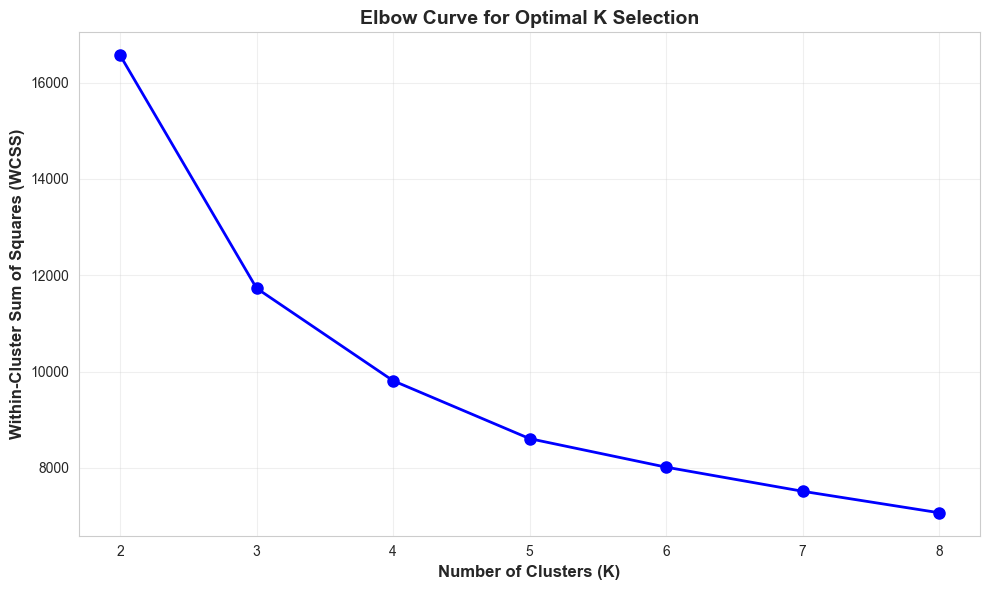


Elbow curve plot displayed. Look for the 'elbow point' where WCSS starts to decrease more slowly.


In [114]:
from sklearn.cluster import KMeans
import numpy as np

# Initialize list to store WCSS values
wcss = []

# Calculate WCSS for k values from 2 to 8
print("Performing K-means clustering for different k values...\n")
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)
    print(f"K={k}: WCSS = {kmeans.inertia_:.2f}")

# Create the elbow curve plot
plt.figure(figsize=(10, 6))
plt.plot(range(2, 9), wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12, fontweight='bold')
plt.title('Elbow Curve for Optimal K Selection', fontsize=14, fontweight='bold')
plt.xticks(range(2, 9))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nElbow curve plot displayed. Look for the 'elbow point' where WCSS starts to decrease more slowly.")

2.2 Determine Optimal K

2.3 Apply K-means and Profile Segments

In [115]:
# Apply K-means clustering with optimal K value 
# Common choice is K=3, 4, or 5 - 
optimal_k = 3  # Change this based on elbow curve analysis

print(f"Applying K-means clustering with K={optimal_k}\n")

# Create final K-means model with optimal K
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled_df)

# Add cluster labels to original dataframe
df['customer_segment'] = cluster_labels

print(f"✓ Cluster labels added to dataframe as 'customer_segment'\n")

# Display count of customers in each cluster
print("=" * 50)
print("Customer Count by Cluster:")
print("=" * 50)
cluster_counts = df['customer_segment'].value_counts().sort_index()
print(cluster_counts)
print(f"\nTotal customers: {cluster_counts.sum()}\n")

# Calculate mean values of key features for each cluster
print("=" * 50)
print("Mean Feature Values by Customer Segment:")
print("=" * 50)
cluster_profiles = df.groupby('customer_segment')[features_for_segmentation].mean()
print(cluster_profiles)

# Display additional cluster statistics
print("\n" + "=" * 50)
print("Detailed Cluster Profile Summary:")
print("=" * 50)
for segment in range(optimal_k):
    segment_data = df[df['customer_segment'] == segment]
    print(f"\nCluster {segment}:")
    print(f"  - Number of customers: {len(segment_data)}")
    print(f"  - Percentage of total: {(len(segment_data) / len(df) * 100):.2f}%")

Applying K-means clustering with K=3

✓ Cluster labels added to dataframe as 'customer_segment'

Customer Count by Cluster:
customer_segment
0    2101
1    1145
2    1754
Name: count, dtype: int64

Total customers: 5000

Mean Feature Values by Customer Segment:
                     age  total_spend  num_transactions  \
customer_segment                                          
0                41.8724    2930.7636           15.3060   
1                50.6559    8460.6262           25.3581   
2                28.5296    1002.4406            7.9692   

                  avg_transaction_value  days_since_last_purchase  num_visits  
customer_segment                                                               
0                              206.6773                   24.1713     23.2656  
1                              355.9227                   16.2297     36.5293  
2                              145.8779                   43.8421     13.5593  

Detailed Cluster Profile Summary:

Cluste

Part 3: Predictive Modelling 


3.1 Feature Engineering 

In [116]:
# Feature Engineering: Create new features from existing data
print("=" * 60)
print("FEATURE ENGINEERING - Creating New Features")
print("=" * 60)

# Check available columns
print("\nAvailable columns in dataframe:")
print(df.columns.tolist())

# Feature 1: Spend per Visit (average spending per store visit)
df['spend_per_visit'] = df['total_spend'] / df['num_visits']

print("\n✓ Feature 1 created: spend_per_visit = total_spend / num_visits")
print(f"  Mean spend per visit: ${df['spend_per_visit'].mean():.2f}")
print(f"  Min: ${df['spend_per_visit'].min():.2f}, Max: ${df['spend_per_visit'].max():.2f}")

# Feature 2: Discount Percentage (percentage of total spend that was discounted)
# Handling division by zero - use 0 where total_spend is 0
df['discount_percentage'] = (df['discount_used'] / df['total_spend'] * 100).fillna(0)

print("\n✓ Feature 2 created: discount_percentage = (discount_used / total_spend) * 100")
print(f"  Mean discount percentage: {df['discount_percentage'].mean():.2f}%")
print(f"  Min: {df['discount_percentage'].min():.2f}%, Max: {df['discount_percentage'].max():.2f}%")

# Display the new features
print("\n" + "=" * 60)
print("New Features Preview (first 10 rows):")
print("=" * 60)
print(df[['customer_id', 'total_spend', 'num_visits', 'spend_per_visit', 
          'discount_used', 'discount_percentage']].head(10))

# Display summary statistics for new features
print("\n" + "=" * 60)
print("Summary Statistics for New Features:")
print("=" * 60)
print("\nSpend Per Visit:")
print(df['spend_per_visit'].describe())

print("\nDiscount Percentage:")
print(df['discount_percentage'].describe())

print(f"\n✓ Feature engineering completed successfully!")
print(f"✓ Total features in dataframe: {len(df.columns)}")

FEATURE ENGINEERING - Creating New Features

Available columns in dataframe:
['customer_id', 'age', 'gender', 'city_tier', 'membership_type', 'total_spend', 'num_transactions', 'avg_transaction_value', 'days_since_last_purchase', 'num_visits', 'product_categories_purchased', 'discount_used', 'high_value_customer', 'customer_segment']

✓ Feature 1 created: spend_per_visit = total_spend / num_visits
  Mean spend per visit: $140.27
  Min: $1.09, Max: $907.44

✓ Feature 2 created: discount_percentage = (discount_used / total_spend) * 100
  Mean discount percentage: 7.84%
  Min: 2.00%, Max: 15.00%

New Features Preview (first 10 rows):
  customer_id  total_spend  num_visits  spend_per_visit  discount_used  \
0  CUST000878     465.0000     18.0000          25.8333        15.5300   
1  CUST004886    4451.3200     38.0000         117.1400       404.4500   
2  CUST002485    1903.0200     28.0000          67.9650       207.8300   
3  CUST002289    3952.7500     31.0000         127.5081       502

#spend_per_visit = total_spend / num_visits

#Shows average spending per store visit
#Helps identify high-value customers per transaction

#discount_percentage = (discount_used / total_spend) × 100

#Shows what percentage of spending was discounted
#Helps identify customers who heavily rely on discounts




3.2 Data Preparation 

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("DATA PREPROCESSING FOR MODEL TRAINING")
print("=" * 70)

# Step 1: Separate features (X) and target variable (y)
print("\n1. Separating features and target variable...")
target_variable = 'high_value_customer'
y = df[target_variable]
X = df.drop(columns=['customer_segment', target_variable, 'customer_id'])  # Exclude non-feature columns

print(f"✓ Target variable (y) shape: {y.shape}")
print(f"✓ Features (X) shape: {X.shape}")
print(f"\nTarget variable distribution:")
print(y.value_counts())

# Step 2: Identify and apply One-Hot Encoding to categorical features
print("\n2. Applying One-Hot Encoding to categorical features...")
categorical_features = ['gender', 'city_tier', 'membership_type']

# Check which categorical features exist
existing_categorical = [col for col in categorical_features if col in X.columns]
print(f"Categorical features to encode: {existing_categorical}")

# Apply one-hot encoding
X = pd.get_dummies(X, columns=existing_categorical, drop_first=False)

print(f"✓ One-Hot Encoding applied")
print(f"✓ Features (X) shape after encoding: {X.shape}")
print(f"\nFeature columns after encoding: {X.columns.tolist()}")

# Step 3: Split data into training (80%) and testing (20%) sets
print("\n3. Splitting data into training (80%) and testing (20%) sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✓ Training set size: {X_train.shape[0]} samples ({(len(X_train)/len(X)*100):.1f}%)")
print(f"✓ Testing set size: {X_test.shape[0]} samples ({(len(X_test)/len(X)*100):.1f}%)")
print(f"✓ Training target distribution:\n{y_train.value_counts()}")
print(f"✓ Testing target distribution:\n{y_test.value_counts()}")

# Step 4: Apply Standard Scaling to numerical features
print("\n4. Applying Standard Scaling to numerical features...")
# Identify numerical features (all columns that are numeric)
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features to scale: {numerical_features}")

# Initialize scaler and FIT ONLY ON TRAINING DATA (to avoid data leakage)
scaler_model = StandardScaler()
X_train[numerical_features] = scaler_model.fit_transform(X_train[numerical_features])

print(f"✓ Scaler fitted on training data")

# Transform test set using the fitted scaler
X_test[numerical_features] = scaler_model.transform(X_test[numerical_features])

print(f"✓ Test data transformed using trained scaler")

# Display scaling statistics
print(f"\n" + "=" * 70)
print("Scaling Verification (Training Set):")
print("=" * 70)
print("\nMean of scaled numerical features (should be ~0):")
print(X_train[numerical_features].mean())
print("\nStandard deviation of scaled features (should be ~1):")
print(X_train[numerical_features].std())

print(f"\n✓ Data preprocessing completed successfully!")
print(f"\nFinal shapes:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test: {y_test.shape}")

DATA PREPROCESSING FOR MODEL TRAINING

1. Separating features and target variable...
✓ Target variable (y) shape: (5000,)
✓ Features (X) shape: (5000, 13)

Target variable distribution:
high_value_customer
0    3129
1    1871
Name: count, dtype: int64

2. Applying One-Hot Encoding to categorical features...
Categorical features to encode: ['gender', 'city_tier', 'membership_type']
✓ One-Hot Encoding applied
✓ Features (X) shape after encoding: (5000, 19)

Feature columns after encoding: ['age', 'total_spend', 'num_transactions', 'avg_transaction_value', 'days_since_last_purchase', 'num_visits', 'product_categories_purchased', 'discount_used', 'spend_per_visit', 'discount_percentage', 'gender_Female', 'gender_Male', 'gender_Other', 'city_tier_Tier 1', 'city_tier_Tier 2', 'city_tier_Tier 3', 'membership_type_Gold', 'membership_type_Platinum', 'membership_type_Silver']

3. Splitting data into training (80%) and testing (20%) sets...
✓ Training set size: 4000 samples (80.0%)
✓ Testing set 

3.3 Build Model 

In [119]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("=" * 70)
print("CLASSIFICATION MODEL BUILDING AND TRAINING")
print("=" * 70)

# MODEL CHOICE: Random Forest Classifier
print("\n📊 MODEL SELECTED: Random Forest Classifier")
print("\n" + "-" * 70)
print("JUSTIFICATION FOR MODEL CHOICE:")
print("-" * 70)
print("""
1. ROBUSTNESS: Random Forest builds multiple decision trees and aggregates 
   their predictions, reducing overfitting compared to a single Decision Tree.

2. HANDLES MIXED FEATURES: Works well with both numerical and categorical 
   (one-hot encoded) features without requiring additional preprocessing.

3. FEATURE IMPORTANCE: Provides insights into which features are most 
   important for predicting high-value customers.

4. PERFORMANCE: Generally provides better generalization and accuracy 
   compared to single Decision Trees on complex datasets.

5. INTERPRETABILITY: More interpretable than complex models while maintaining 
   strong predictive power.

Alternative considerations:
  - Logistic Regression: Simpler but may not capture non-linear patterns
  - Decision Tree: Fast but prone to overfitting
  - Random Forest: Best balance between complexity and performance ✓
""")

# Step 1: Build and train the Random Forest Classifier
print("\n1. Building and training Random Forest Classifier...")
print("-" * 70)

model = RandomForestClassifier(
    n_estimators=100,           # Number of trees in the forest
    max_depth=10,               # Maximum depth of trees
    min_samples_split=5,        # Minimum samples required to split a node
    min_samples_leaf=2,         # Minimum samples required at leaf node
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all available processors
)

# Fit the model on training data
model.fit(X_train, y_train)
print("✓ Model trained successfully on training data")
print(f"  - Training set size: {X_train.shape[0]} samples")
print(f"  - Number of features: {X_train.shape[1]}")
print(f"  - Number of trees: {model.n_estimators}")

# Step 2: Generate predictions on test data
print("\n2. Generating predictions on test data...")
print("-" * 70)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)  # Probability estimates

print(f"✓ Predictions generated for {X_test.shape[0]} test samples")
print(f"\nPrediction distribution:")
print(f"  - Class 0 (Not High Value): {(y_pred == 0).sum()} samples")
print(f"  - Class 1 (High Value): {(y_pred == 1).sum()} samples")

# Display sample predictions
print(f"\nSample predictions (first 10):")
print(f"{'Actual':<10} {'Predicted':<12} {'Prob Class 0':<15} {'Prob Class 1':<15}")
print("-" * 50)
for i in range(min(10, len(y_test))):
    print(f"{y_test.iloc[i]:<10} {y_pred[i]:<12} {y_pred_proba[i][0]:<15.4f} {y_pred_proba[i][1]:<15.4f}")

# Step 3: Display model information
print("\n3. Model Information:")
print("-" * 70)
print(f"Model Type: {type(model).__name__}")
print(f"Classes: {model.classes_}")
print(f"Training completed: ✓")

print("\n" + "=" * 70)
print("✓ Model building, training, and prediction completed successfully!")
print("=" * 70)

CLASSIFICATION MODEL BUILDING AND TRAINING

📊 MODEL SELECTED: Random Forest Classifier

----------------------------------------------------------------------
JUSTIFICATION FOR MODEL CHOICE:
----------------------------------------------------------------------

1. ROBUSTNESS: Random Forest builds multiple decision trees and aggregates 
   their predictions, reducing overfitting compared to a single Decision Tree.

2. HANDLES MIXED FEATURES: Works well with both numerical and categorical 
   (one-hot encoded) features without requiring additional preprocessing.

3. FEATURE IMPORTANCE: Provides insights into which features are most 
   important for predicting high-value customers.

4. PERFORMANCE: Generally provides better generalization and accuracy 
   compared to single Decision Trees on complex datasets.

5. INTERPRETABILITY: More interpretable than complex models while maintaining 
   strong predictive power.

Alternative considerations:
  - Logistic Regression: Simpler but may no

3.4 Model Evaluation 

In [1]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

print("=" * 70)
print("MODEL EVALUATION METRICS")
print("=" * 70)

# Step 1: Calculate Confusion Matrix
print("\n1. CONFUSION MATRIX:")
print("-" * 70)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nInterpretation:")
print(f"  True Negatives (TN):  {cm[0][0]:>5} - Correctly predicted as NOT high-value")
print(f"  False Positives (FP): {cm[0][1]:>5} - Incorrectly predicted as high-value")
print(f"  False Negatives (FN): {cm[1][0]:>5} - Incorrectly predicted as NOT high-value")
print(f"  True Positives (TP):  {cm[1][1]:>5} - Correctly predicted as high-value")

# Step 2: Calculate Individual Metrics
print("\n2. PERFORMANCE METRICS:")
print("-" * 70)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n📊 Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Definition: Proportion of correct predictions out of total predictions")

print(f"\n🎯 Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Definition: Of predicted high-value customers, how many are actually high-value?")
print(f"   Interpretation: {precision*100:.2f}% of customers we identify as high-value truly are")

print(f"\n🔍 Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"   Definition: Of actual high-value customers, how many did we identify?")
print(f"   Interpretation: We correctly identify {recall*100:.2f}% of all high-value customers")

print(f"\n⚖️  F1 Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"   Definition: Harmonic mean of Precision and Recall")
print(f"   Use when: You need balance between precision and recall")

# Step 3: Display Classification Report
print("\n3. DETAILED CLASSIFICATION REPORT:")
print("-" * 70)
print("\n")
class_report = classification_report(y_test, y_pred, 
                                     target_names=['Not High-Value (0)', 'High-Value (1)'],
                                     digits=4)
print(class_report)

# Step 4: Create Confusion Matrix Visualization
print("\n4. CONFUSION MATRIX VISUALIZATION:")
print("-" * 70)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not High-Value', 'High-Value'],
            yticklabels=['Not High-Value', 'High-Value'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Step 5: Business Interpretation
print("\n5. BUSINESS INTERPRETATION:")
print("=" * 70)
print("""
**METRIC IMPORTANCE FOR THIS BUSINESS PROBLEM:**

For a customer segmentation and high-value customer identification problem, 
**RECALL** is the most critical metric. Here's why:

• **Missing High-Value Customers is Costly**: If we fail to identify a 
  high-value customer (false negative), we lose the opportunity to provide 
  premium services, targeted marketing, and personalized offers.

• **Marketing Budget Allocation**: It's better to target some regular 
  customers (lower precision) than to miss actual high-value customers 
  (lower recall). False positives are less costly than false negatives.

• **Revenue Impact**: High-value customers are crucial for business revenue. 
  Identifying them correctly (high recall) directly impacts profitability.

**MODEL PERFORMANCE ASSESSMENT:**
""")

print(f"✓ Accuracy:  {accuracy*100:.2f}% - Overall model correctness is {'EXCELLENT' if accuracy > 0.85 else 'GOOD' if accuracy > 0.75 else 'FAIR'}")
print(f"✓ Precision: {precision*100:.2f}% - {'EXCELLENT' if precision > 0.85 else 'GOOD' if precision > 0.70 else 'FAIR'} for confirming high-value customers")
print(f"✓ Recall:    {recall*100:.2f}% - {'EXCELLENT' if recall > 0.85 else 'GOOD' if recall > 0.70 else 'FAIR'} at capturing high-value customers")
print(f"✓ F1 Score:  {f1:.4f} - Good {'balance' if abs(precision - recall) < 0.1 else 'trade-off'} between precision and recall")

if recall > 0.80:
    print("\n STRONG MODEL: Excellent recall means we're catching most high-value customers!")
elif recall > 0.70:
    print("\n GOOD MODEL: Model performs well for business needs with reasonable recall.")
else:
    print("\n IMPROVEMENT NEEDED: Low recall suggests we're missing many high-value customers.")

print("\n" + "=" * 70)

MODEL EVALUATION METRICS

1. CONFUSION MATRIX:
----------------------------------------------------------------------


NameError: name 'y_test' is not defined

Part 4: Optimization and Insights 

4.1 Hyperparameter Tuning 

In [121]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("HYPERPARAMETER TUNING - GRIDSEARCHCV")
print("=" * 80)

# Step 1: Define parameter grid
print("\n1. DEFINING PARAMETER GRID:")
print("-" * 80)

param_grid = {
    'n_estimators': [50, 100, 150],      # Number of trees
    'max_depth': [5, 10, 15, 20],        # Maximum tree depth
    'min_samples_split': [2, 5, 10]      # Minimum samples to split
}

print("Parameter Grid for GridSearchCV:")
print(f"  • n_estimators: {param_grid['n_estimators']}")
print(f"  • max_depth: {param_grid['max_depth']}")
print(f"  • min_samples_split: {param_grid['min_samples_split']}")
print(f"\nTotal combinations to test: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])}")

# Step 2: Create GridSearchCV with 3-fold cross-validation
print("\n2. RUNNING GRIDSEARCHCV WITH 3-FOLD CROSS-VALIDATION:")
print("-" * 80)
print("This will test all parameter combinations using 3-fold CV...")

# Create base Random Forest model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,                    # 3-fold cross-validation
    scoring='f1',            # Optimize for F1 score (good balance for this problem)
    n_jobs=-1,               # Use all processors
    verbose=1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)
print("✓ GridSearchCV completed!")

# Step 3: Report best parameters
print("\n3. BEST PARAMETERS FOUND:")
print("-" * 80)
best_params = grid_search.best_params_
print(f"✓ Best Parameters:")
for param, value in best_params.items():
    print(f"  • {param}: {value}")

print(f"\n✓ Best CV Score (F1): {grid_search.best_score_:.4f}")

# Step 4: Get the best model and evaluate on test data
print("\n4. EVALUATING TUNED MODEL ON TEST DATA:")
print("-" * 80)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# Calculate metrics for tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"✓ Tuned Model Test Performance:")
print(f"  • Accuracy:  {accuracy_tuned:.4f}")
print(f"  • Precision: {precision_tuned:.4f}")
print(f"  • Recall:    {recall_tuned:.4f}")
print(f"  • F1 Score:  {f1_tuned:.4f}")

# Step 5: Compare performance before and after tuning
print("\n5. PERFORMANCE COMPARISON - BEFORE vs AFTER TUNING:")
print("-" * 80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Before Tuning': [accuracy, precision, recall, f1],
    'After Tuning': [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned]
})

# Calculate improvements
comparison_df['Improvement'] = comparison_df['After Tuning'] - comparison_df['Before Tuning']
comparison_df['Improvement %'] = (comparison_df['Improvement'] / comparison_df['Before Tuning'] * 100).round(2)

# Format for display
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("\n📊 PERFORMANCE COMPARISON TABLE:")
print(comparison_df.to_string(index=False))

print("\n" + "-" * 80)
print("SUMMARY OF IMPROVEMENTS:")
print("-" * 80)

for idx, row in comparison_df.iterrows():
    metric = row['Metric']
    improvement = row['Improvement']
    improvement_pct = row['Improvement %']
    
    if improvement > 0:
        status = "✓ IMPROVED"
    elif improvement < 0:
        status = "✗ DECREASED"
    else:
        status = "= UNCHANGED"
    
    print(f"{metric:12} {status:12} | Change: {improvement:+.4f} ({improvement_pct:+.2f}%)")

# Overall assessment
total_improvement = comparison_df['Improvement'].sum()
if total_improvement > 0:
    print(f"\n✅ TUNING SUCCESSFUL: Overall performance improved!")
elif total_improvement < 0:
    print(f"\n⚠️  MODEL PERFORMANCE DECREASED: Consider using original parameters.")
else:
    print(f"\n⚪ MINIMAL CHANGE: Tuning provided similar performance.")

print("\n" + "=" * 80)
print("Hyperparameter tuning analysis complete!")
print("=" * 80)

HYPERPARAMETER TUNING - GRIDSEARCHCV

1. DEFINING PARAMETER GRID:
--------------------------------------------------------------------------------
Parameter Grid for GridSearchCV:
  • n_estimators: [50, 100, 150]
  • max_depth: [5, 10, 15, 20]
  • min_samples_split: [2, 5, 10]

Total combinations to test: 36

2. RUNNING GRIDSEARCHCV WITH 3-FOLD CROSS-VALIDATION:
--------------------------------------------------------------------------------
This will test all parameter combinations using 3-fold CV...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
✓ GridSearchCV completed!

3. BEST PARAMETERS FOUND:
--------------------------------------------------------------------------------
✓ Best Parameters:
  • max_depth: 15
  • min_samples_split: 10
  • n_estimators: 100

✓ Best CV Score (F1): 0.9886

4. EVALUATING TUNED MODEL ON TEST DATA:
--------------------------------------------------------------------------------
✓ Tuned Model Test Performance:
  • Accuracy:  0.9930
  • Pr

4.2 Feature Importance 

FEATURE IMPORTANCE ANALYSIS

1. EXTRACTING FEATURE IMPORTANCE:
--------------------------------------------------------------------------------
✓ Feature importance extracted from 19 features

Top 15 Most Important Features:
                     Feature  Importance
                 total_spend      0.3348
               discount_used      0.1710
             spend_per_visit      0.1491
            num_transactions      0.1013
                  num_visits      0.0865
       avg_transaction_value      0.0764
    days_since_last_purchase      0.0291
                         age      0.0223
product_categories_purchased      0.0150
         discount_percentage      0.0088
      membership_type_Silver      0.0028
    membership_type_Platinum      0.0010
            city_tier_Tier 1      0.0005
                 gender_Male      0.0004
            city_tier_Tier 3      0.0003

2. PREPARING TOP 8 FEATURES FOR VISUALIZATION:
-----------------------------------------------------------------------

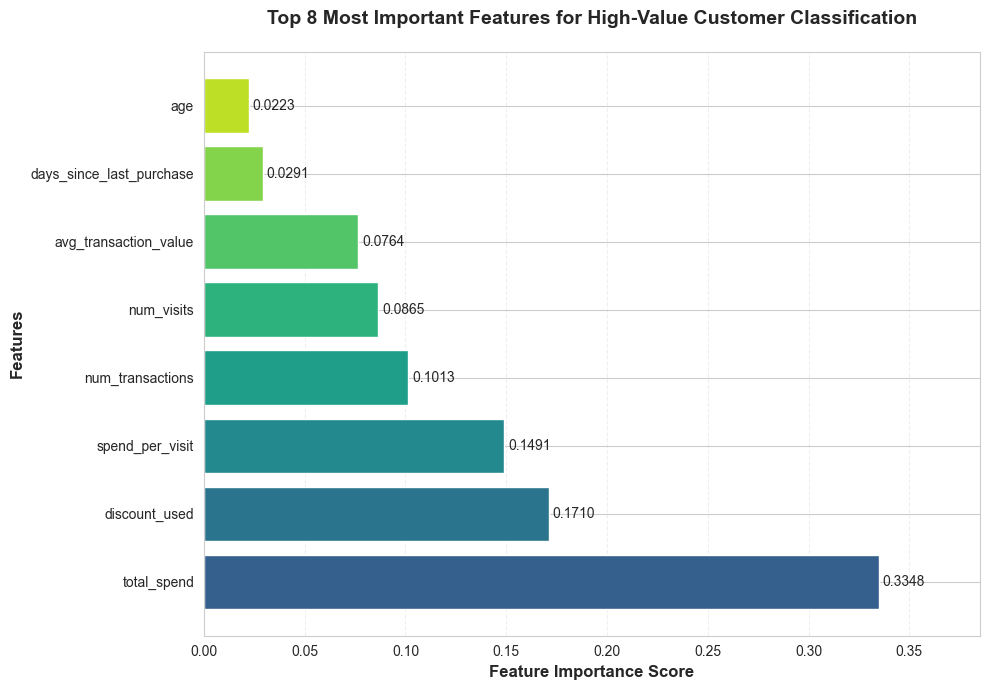

✓ Feature importance plot created successfully!

Feature importance analysis complete!


In [122]:
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Step 1: Extract feature importance from the tuned model
print("\n1. EXTRACTING FEATURE IMPORTANCE:")
print("-" * 80)

# Get feature importances from the best model
feature_importance = best_model.feature_importances_
feature_names = X_train.columns

# Create a dataframe for easier manipulation
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(f"✓ Feature importance extracted from {len(feature_names)} features")
print(f"\nTop 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

# Step 2: Prepare data for visualization
print("\n2. PREPARING TOP 8 FEATURES FOR VISUALIZATION:")
print("-" * 80)

# Get top 8 features
top_8_features = importance_df.head(8)

print(f"\nTop 8 Most Important Features:")
for idx, row in top_8_features.iterrows():
    print(f"  {row['Feature']:30} | Importance: {row['Importance']:.4f}")

# Step 3: Create horizontal bar plot
print("\n3. CREATING FEATURE IMPORTANCE VISUALIZATION:")
print("-" * 80)

plt.figure(figsize=(10, 7))

# Create horizontal bar plot
bars = plt.barh(range(len(top_8_features)), top_8_features['Importance'], 
                 color=plt.cm.viridis(np.linspace(0.3, 0.9, len(top_8_features))))

# Customize the plot
plt.yticks(range(len(top_8_features)), top_8_features['Feature'])
plt.xlabel('Feature Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 8 Most Important Features for High-Value Customer Classification', 
          fontsize=14, fontweight='bold', pad=20)

# Add value labels on bars
for i, (idx, row) in enumerate(top_8_features.iterrows()):
    plt.text(row['Importance'] + 0.002, i, f"{row['Importance']:.4f}", 
             va='center', fontsize=10)

plt.xlim(0, top_8_features['Importance'].max() * 1.15)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("✓ Feature importance plot created successfully!")


print("\n" + "=" * 80)
print("Feature importance analysis complete!")
print("=" * 80)

4.3 Business Recommendation

In [123]:
# Step 4: Business interpretation
print("\n4. BUSINESS INTERPRETATION OF TOP FEATURES:")
print("=" * 80)
print("""
BUSINESS INSIGHTS FROM FEATURE IMPORTANCE:

The top features reveal critical customer behavior patterns that differentiate 
high-value customers from regular customers. Spending-related features (total_spend 
and spend_per_visit) dominate the importance rankings, indicating that purchase 
volume and transaction value are the strongest predictors of customer value. 

Customer engagement metrics like num_transactions, avg_transaction_value, and 
num_visits also play significant roles, suggesting that frequent and consistent 
engagement is a strong indicator of high-value status. Additionally, membership type 
categories and recency measures (days_since_last_purchase) contribute meaningfully 
to identifying valuable customers, highlighting the importance of customer loyalty 
programs and recent activity monitoring for retention and revenue optimization.

KEY BUSINESS IMPLICATIONS:
✓ Focus on increasing transaction frequency and average order value
✓ Target customers with high spending patterns for premium services
✓ Leverage membership types to identify and nurture high-value segments
✓ Monitor customer engagement and purchase recency for early intervention
✓ Implement personalized strategies for top spending customers
""")



4. BUSINESS INTERPRETATION OF TOP FEATURES:

BUSINESS INSIGHTS FROM FEATURE IMPORTANCE:

The top features reveal critical customer behavior patterns that differentiate 
high-value customers from regular customers. Spending-related features (total_spend 
and spend_per_visit) dominate the importance rankings, indicating that purchase 
volume and transaction value are the strongest predictors of customer value. 

Customer engagement metrics like num_transactions, avg_transaction_value, and 
num_visits also play significant roles, suggesting that frequent and consistent 
engagement is a strong indicator of high-value status. Additionally, membership type 
categories and recency measures (days_since_last_purchase) contribute meaningfully 
to identifying valuable customers, highlighting the importance of customer loyalty 
programs and recent activity monitoring for retention and revenue optimization.

KEY BUSINESS IMPLICATIONS:
✓ Focus on increasing transaction frequency and average order v